# AdaBoost: Adaptive Boosting 

AdaBoost (short for **Adaptive Boosting**) is a machine learning algorithm that combines many **weak learners** into one **strong learner**.

It is most commonly used for **classification** problems.

## Core Idea

Instead of training one powerful model, AdaBoost trains many simple models sequentially:

1. Train a weak model (often a small decision tree called a *decision stump*)
2. Find which training examples it got wrong
3. Increase the importance (weight) of those misclassified examples
4. Train the next model focusing more on the hard examples
5. Repeat many times
6. Combine all weak models into a final prediction

The models “boost” each other’s performance.

---

## Simple Intuition

Imagine a teacher helping students:

* First test: identify struggling students
* Next lesson: spend more time on students who performed poorly
* Repeat until most students improve

AdaBoost works similarly by focusing more and more on difficult data points.

---

## Mathematical View

The final classifier is a weighted combination of weak learners:

$$
F(x)=\sum_{t=1}^{T}\alpha_t h_t(x)
$$

Where:

* $(h_t(x))$ = weak learner at step $(t)$
* $(\alpha_t)$ = importance weight of that learner
* $(T)$ = number of learners

Better learners get higher weights.

---

## AdaBoost Algorithm Steps

For binary classification:

1. Assign equal weights to all training samples
2. Train weak learner
3. Compute error rate
4. Compute learner weight:
$$
\alpha_t=\frac{1}{2}\ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)
$$
5. Increase weights of misclassified samples
6. Normalize weights
7. Repeat

---

## Why It Works Well

Advantages:

* Simple and powerful
* Often achieves high accuracy
* Reduces bias and variance
* Works well with decision trees

---

## Limitations

Disadvantages:

* Sensitive to noisy data and outliers
* Sequential training can be slower
* Can overfit if too many weak learners are added

---

## Common Weak Learner

AdaBoost usually uses:

* Decision stumps (1-level decision trees)

Because even very simple models can become powerful when combined.

---

## Example Applications

* Face detection
* Spam filtering
* Fraud detection
* Medical diagnosis

---

## AdaBoost vs Gradient Boosting

| AdaBoost                         | Gradient Boosting         |
| -------------------------------- | ------------------------- |
| Reweights data points            | Fits residual errors      |
| Focuses on misclassified samples | Optimizes a loss function |
| Simpler                          | More flexible/powerful    |
| Less common today                | Basis of XGBoost/LightGBM |

---

# What is Boosting? 

**Boosting** is a machine learning technique where multiple **weak models** are combined step-by-step to create a **strong model**.

The main idea is:

> Each new model tries to fix the mistakes made by the previous models.

---

## Simple Definition

Boosting =
**Sequentially improving weak learners by focusing on errors**

---

## How It Works

Suppose you have a dataset.

### Step 1

Train a weak model
→ It makes some mistakes.

### Step 2

Train another model focusing more on the mistakes.

### Step 3

Train another model to improve further.

### Final

Combine all models into one strong predictor.

---

## Main Goal of Boosting

Boosting mainly aims to:

* Increase prediction accuracy
* Reduce bias
* Turn weak learners into strong learners

---

## Weak Learner Example

A weak learner is a model that performs only slightly better than random guessing.

Common example:

* Small decision tree (decision stump)

---

## Key Characteristic

Unlike Bagging, Boosting trains models:

* **Sequentially**
* Not independently

Each model depends on previous models.

---

## Popular Boosting Algorithms

1. AdaBoost
2. Gradient Boosting
3. XGBoost
4. LightGBM
5. CatBoost

---

## Simple Analogy

Imagine learning math:

* First teacher explains basics
* Second teacher focuses on your weak areas
* Third teacher fixes remaining confusion

Together, they help you become strong.

That is essentially boosting.

---

## Boosting vs Bagging

| Boosting                         | Bagging            |
| -------------------------------- | ------------------ |
| Sequential learning              | Parallel learning  |
| Focuses on mistakes              | Random sampling    |
| Reduces bias                     | Reduces variance   |
| Models depend on previous models | Models independent |

---

## Basic Formula Idea

The final prediction is the weighted sum of multiple learners:
$$
F(x)=\sum_{m=1}^{M}\alpha_m h_m(x)
$$
Where:

* $(h_m(x))$ = weak learner
* $(\alpha_m)$ = importance weight
* $(M)$ = number of models


In [56]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [57]:
X, y = load_breast_cancer(return_X_y=True)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (426, 30)
Testing set shape: (143, 30)


In [59]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
y_pred_stump = stump.predict(X_test)
print("Decision Stump Accuracy:", accuracy_score(y_test, y_pred_stump))
print("Classification Report:\n", classification_report(y_test, y_pred_stump))

Decision Stump Accuracy: 0.8951048951048951
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        54
           1       0.95      0.88      0.91        89

    accuracy                           0.90       143
   macro avg       0.89      0.90      0.89       143
weighted avg       0.90      0.90      0.90       143



In [68]:
base_learner = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_clf = AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=100,
    learning_rate=0.3,
    random_state=42
)

ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.958041958041958
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [69]:
y_pred_ada = ada_clf.predict(X_test)
print("AdaBoostClassifier Accuracy:", accuracy_score(y_test, y_pred_ada))

AdaBoostClassifier Accuracy: 0.958041958041958


In [70]:
cm = confusion_matrix(y_test, y_pred_ada)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[51  3]
 [ 3 86]]


In [71]:
# # Creating graph for accuracies on different parameters
# import seaborn as sns
# max_depth_range = [1, 2, 3, 4, 5]
# n_estimators_range = [10, 50, 100, 200, 500, 1000]
# learning_rate_range = [0.01, 0.1, 0.5, 1.0, 1.5, 2.0]
# results = []

# for max_depth in max_depth_range:
#     for n_estimators in n_estimators_range:
#         for learning_rate in learning_rate_range:
#             base_learner = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
#             ada_clf = AdaBoostClassifier(
#                 estimator=base_learner,
#                 n_estimators=n_estimators,
#                 learning_rate=learning_rate,
#                 random_state=42
#             )
#             ada_clf.fit(X_train, y_train)
#             y_pred = ada_clf.predict(X_test)
#             acc = accuracy_score(y_test, y_pred)
#             results.append((max_depth, n_estimators, learning_rate, acc))
            
# results_df = pd.DataFrame(results, columns=['max_depth', 'n_estimators', 'learning_rate', 'accuracy'])
# pivot_table = results_df.pivot_table(values='accuracy', index='max_depth', columns='n_estimators')
# plt.figure(figsize=(12, 6))
# sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="YlGnBu")
# plt.title("AdaBoost Accuracy for Different max_depth and n_estimators")
# plt.xlabel("n_estimators")
# plt.ylabel("max_depth")
# plt.show()

In [72]:
# results_df.sort_values(by='accuracy', ascending=False).head(10)

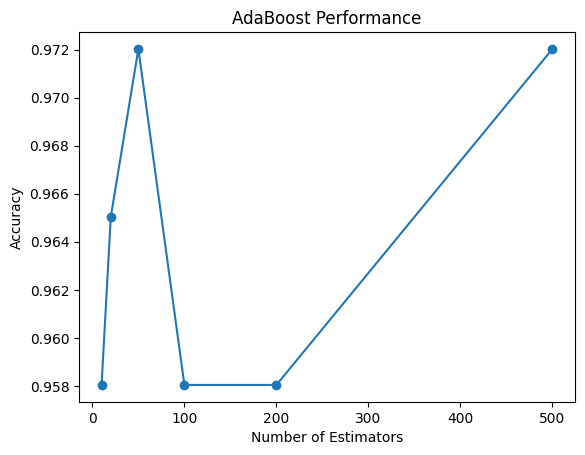

In [73]:
estimators = [10, 20, 50, 100, 200, 500]
accuracies = []

for n in estimators:
    model = AdaBoostClassifier(
        estimator = base_learner,
        n_estimators = n,
        learning_rate = 0.3,
        random_state = 42
    )
    
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))
    

plt.plot(estimators, accuracies, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost Performance')
plt.show()

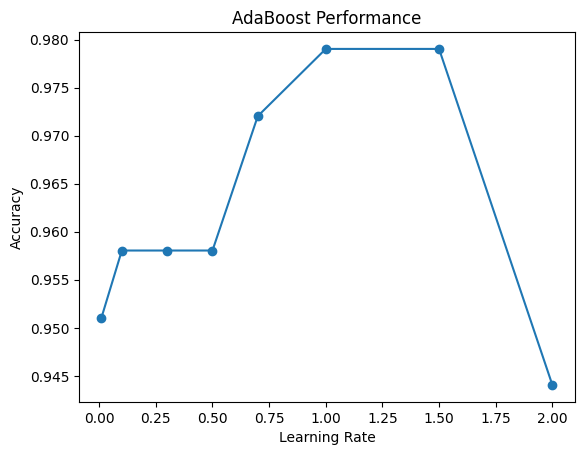

In [77]:
learning_rates = [0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
accuracies = []

for lr in learning_rates:
    model = AdaBoostClassifier(
        estimator = base_learner,
        n_estimators = 100,
        learning_rate = lr,
        random_state = 42
    )
    
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))        
    
plt.plot(learning_rates, accuracies, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('AdaBoost Performance')
plt.show()

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'estimator__max_depth': [1, 2, 3, 4, 5],
    'n_estimators': [10, 50, 100, 200, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
}

grid = GridSearchCV(
    estimator=AdaBoostClassifier(estimator=base_learner, random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

grid.fit(X_train, y_train)


best_model = grid.best_estimator_
y_pred_grid = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("\nTest Accuracy (GridSearch AdaBoost):", accuracy_score(y_test, y_pred_grid))
print("\nClassification Report:\n", classification_report(y_test, y_pred_grid)) 



Best Parameters: {'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 500}

Test Accuracy (GridSearch AdaBoost): 0.986013986013986

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       0.99      0.99      0.99        89

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

